In [1]:
# 구글 코랩(Colab)에서 바로 실행 가능 — pandas, matplotlib 기본 설치됨
import urllib.request   # URL로 요청을 보내는 기본 모듈
import urllib.parse     # 한글 검색어를 URL용으로 인코딩
import json             # JSON 문자열 ↔ 파이썬 딕셔너리 변환
import datetime         # 시간 기록

In [2]:
import urllib.request

res = urllib.request.urlopen("https://www.naver.com")
print(type(res))     # <class 'http.client.HTTPResponse'>
print(res.status)    # 200  → 요청 성공
print("--- 헤더 정보 ---")
for h in res.getheaders():
    print(h)

<class 'http.client.HTTPResponse'>
200
--- 헤더 정보 ---
('Date', 'Thu, 04 Jun 2026 02:20:51 GMT')
('content-type', 'text/html; charset=UTF-8')
('transfer-encoding', 'chunked')
('set-cookie', 'PM_CK_loc=6a99d2fc1b5471d9d14cea36ec9cb8ccbc593048dad883183ee247e5610d9706; Expires=Fri, 05 Jun 2026 02:20:51 GMT; Path=/; HttpOnly')
('cache-control', 'no-cache, no-store, must-revalidate')
('pragma', 'no-cache')
('x-frame-options', 'DENY')
('strict-transport-security', 'max-age=63072000; includeSubdomains')
('referrer-policy', 'unsafe-url')
('server', 'nfront')
('connection', 'close')


In [ ]:
import os
import urllib.request
import urllib.parse
from dotenv import load_dotenv

# 1) .env 파일의 환경변수 로드
load_dotenv()

# 2) os.environ을 통해 안전하게 값 가져오기
client_id = os.environ.get("NAVER_CLIENT_ID")
client_secret = os.environ.get("NAVER_CLIENT_SECRET")

# 한글 검색어 -> URL 인코딩 필수
encText = urllib.parse.quote("애플")
url = "https://openapi.naver.com/v1/search/blog?query=" + encText

request = urllib.request.Request(url)
request.add_header("X-Naver-Client-Id", client_id)
request.add_header("X-Naver-Client-Secret", client_secret)

response = urllib.request.urlopen(request)
if response.getcode() == 200:
    body = response.read().decode("utf-8")
    print(body)
else:
    print("Error Code:", response.getcode())

{
	"lastBuildDate":"Thu, 04 Jun 2026 11:34:40 +0900",
	"total":8165815,
	"start":1,
	"display":10,
	"items":[
		{
			"title":"뉴욕 여행 준비는 빅<b>애플<\/b>패스 뉴욕 3대 패스 비교 및 추천",
			"link":"https:\/\/blog.naver.com\/be_ok-\/224294982259",
			"description":"뉴욕 여행 준비는 빅<b>애플<\/b>패스 뉴욕 3대 패스 비교 및 추천 안녕하세요! 여행 인플루언서 홍지구입니다... 지구가 찾아봤던 뉴욕 3대 패스를 한 번 비교해보고 지구가 선택한 빅<b>애플<\/b>패스가 어떤 장점이... ",
			"bloggername":"오늘도, 지구 여행",
			"bloggerlink":"blog.naver.com\/be_ok-",
			"postdate":"20260524"
		},
		{
			"title":"아오모리 골프여행 | <b>애플<\/b>랜드 온천호텔 투숙 후기",
			"link":"https:\/\/blog.naver.com\/trip_pro\/224298640835",
			"description":"이번에 소개해 드릴 곳은 아오모리 골프여행에서 한국인들에게 가장 인기 있는 온천호텔 <b>애플<\/b>랜드입니다. 많은 분들이 궁금해합니다. 왜 아오모리로 골프여행을 가면 시내 호텔이 아닌 <b>애플<\/b>랜드로만 가느냐고... ",
			"bloggername":"바로여행 최팀장의 골프여행",
			"bloggerlink":"blog.naver.com\/trip_pro",
			"postdate":"20260528"
		},
		{
			"title":"<b>애플<\/b>워치 울트라3 추천 리뷰 명품 스포츠 아웃도어 스마트워치",
			"link":"https:\/\/blog.naver.com\/happypanchok\/224301214586",
			"description

In [ ]:
import os
import urllib.request
import urllib.parse
import datetime
import json
from dotenv import load_dotenv

# 1) .env 파일의 환경변수 로드
load_dotenv()

# 2) .env에서 네이버 API 키 안전하게 가져오기
client_id = os.environ.get("NAVER_CLIENT_ID")
client_secret = os.environ.get("NAVER_CLIENT_SECRET")

def getRequestUrl(url):                       # [CODE 1] 공통 요청 함수
    req = urllib.request.Request(url)
    req.add_header("X-Naver-Client-Id", client_id)
    req.add_header("X-Naver-Client-Secret", client_secret)
    try:
        response = urllib.request.urlopen(req)
        if response.getcode() == 200:
            print("[%s] Url Request Success" % datetime.datetime.now())
            return response.read().decode("utf-8")
    except Exception as e:
        print(e)
        return None

def getNaverSearch(node, srcText, start, display):   # [CODE 2] 검색 요청 조립
    base = "https://openapi.naver.com/v1/search"
    node = "/%s.json" % node
    params = "?query=%s&start=%s&display=%s" % (urllib.parse.quote(srcText), start, display)
    responseDecode = getRequestUrl(base + node + params)
    return None if responseDecode is None else json.loads(responseDecode)

def getPostData(post, jsonResult, cnt):              # [CODE 3] 필요한 항목만 추출
    # 블로그 링크 키가 보통 'link' 또는 'bloggerlink'이므로 안전하게 예외 처리 적용
    link = post.get('bloggerlink') if post.get('bloggerlink') else post.get('link', '')
    
    # postdate가 비어있지 않은 경우에만 날짜 포맷팅 진행
    if post.get('postdate'):
        pDate = datetime.datetime.strptime(post['postdate'], '%Y%m%d').strftime('%Y-%m-%d')
    else:
        pDate = "N/A"
        
    jsonResult.append({
        'cnt': cnt, 
        'title': post.get('title', ''),
        'description': post.get('description', ''),
        'link': link, 
        'pDate': pDate
    })

def main():
    node = 'blog'
    srcText = input('검색어를 입력하세요: ')
    cnt = 0
    jsonResult = []
    
    # 최초 데이터 요청
    jsonResponse = getNaverSearch(node, srcText, 1, 100)
    
    # 검색 결과가 없는 경우 방어 코드 추가
    if jsonResponse is None or 'total' not in jsonResponse:
        print("검색 결과가 없거나 오류가 발생했습니다.")
        return
        
    total = jsonResponse['total']
    
    # 최대 1000개까지 호출 가능한 네이버 API 제약조건 및 데이터 바운더리 체크
    while jsonResponse is not None and jsonResponse.get('display', 0) != 0:
        for post in jsonResponse.get('items', []):
            cnt += 1
            getPostData(post, jsonResult, cnt)
            
        start = jsonResponse['start'] + jsonResponse['display']
        
        # 네이버 API는 start 파라미터 최대값이 1000이므로 1000을 넘어가면 중단해야 합니다.
        if start > 1000:
            print("네이버 API 정책상 최대 1000개의 데이터만 수집 가능합니다.")
            break
            
        jsonResponse = getNaverSearch(node, srcText, start, 100)
        
    print('전체 검색: %d 건 / 수집: %d 건' % (total, cnt))
    
    # 결과 파일 저장
    with open('%s_naver_%s.json' % (srcText, node), 'w', encoding='utf8') as f:
        f.write(json.dumps(jsonResult, indent=4, ensure_ascii=False))
    print('저장 완료')

if __name__ == '__main__':
    main()

[2026-06-04 11:34:59.945055] Url Request Success
[2026-06-04 11:35:00.195671] Url Request Success
[2026-06-04 11:35:00.459570] Url Request Success
[2026-06-04 11:35:00.720526] Url Request Success
[2026-06-04 11:35:00.986835] Url Request Success
[2026-06-04 11:35:01.269167] Url Request Success
[2026-06-04 11:35:01.532272] Url Request Success
[2026-06-04 11:35:01.807432] Url Request Success
[2026-06-04 11:35:02.075106] Url Request Success
[2026-06-04 11:35:02.455699] Url Request Success
HTTP Error 400: Bad Request
전체 검색: 1083182 건 / 수집: 1000 건
저장 완료


In [1]:
import urllib.request, urllib.parse, json, ssl, platform, datetime, os
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from dotenv import load_dotenv

# 1) .env 파일의 환경변수 로드
load_dotenv()

# 2) .env에서 공공데이터 API 키 안전하게 가져오기
API_KEY = os.environ.get("DATA_GO_KR_API_KEY")

# 서울 구별 코드 예시
SEOUL_DISTRICTS = {
    "종로구": 110, "중구": 140, "용산구": 170, "성동구": 200,
    "강남구": 680, "서초구": 650, "송파구": 710
}

context = ssl.create_default_context()
context.set_ciphers('DEFAULT@SECLEVEL=1')   # 일부 공공기관 구형 SSL 대응

def set_korean_font():                       # 한글 폰트 (OS 자동 감지)
    os_name = platform.system()
    path = {
        "Windows": "C:/Windows/Fonts/malgun.ttf",
        "Darwin": "/System/Library/Fonts/Supplemental/AppleGothic.ttf"
    }.get(os_name, "/usr/share/fonts/truetype/nanum/NanumGothic.ttf")
    
    plt.rcParams["font.family"] = fm.FontProperties(fname=path).get_name()
    plt.rcParams["axes.unicode_minus"] = False

set_korean_font()

def fetch(searchYearCd, siDo, guGun, numOfRows=100, pageNo=1):
    base = "https://apis.data.go.kr/B552061/frequentzoneBicycle/getRestFrequentzoneBicycle"
    params = {
        "ServiceKey": API_KEY, "searchYearCd": searchYearCd, "siDo": siDo,
        "guGun": guGun, "type": "json", "numOfRows": numOfRows, "pageNo": pageNo
    }
    url = base + "?" + urllib.parse.urlencode(params)   # 파라미터 자동 인코딩
    req = urllib.request.Request(url)
    
    try:
        text = urllib.request.urlopen(req, context=context).read().decode("utf-8")
    except Exception as e:
        print("오류:", e)
        return None
        
    if not text.strip():
        print("응답이 비어있음")
        return None
        
    return json.loads(text)

# 강남구(680) 2023년 사고 다발 지역 수집 및 시각화 예시
data = fetch("2023", "11", "680")

if data and data.get("items"):
    df = pd.DataFrame(data["items"]["item"])
    print(df.head())
    
    df["occrrnc_cnt"] = pd.to_numeric(df["occrrnc_cnt"])  # 발생건수 숫자 변환
    
    plt.figure(figsize=(10, 5))
    plt.bar(df["spot_nm"], df["occrrnc_cnt"], color="skyblue")
    plt.title("2023 서울 강남구 자전거 사고 다발지역")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

오류: HTTP Error 403: Forbidden


In [8]:
import urllib.parse
print(urllib.parse.quote("파이썬 크롤링"))
# %ED%8C%8C%EC%9D%B4%EC%8D%AC%20%ED%81%AC%EB%A1%A4%EB%A7%81

%ED%8C%8C%EC%9D%B4%EC%8D%AC%20%ED%81%AC%EB%A1%A4%EB%A7%81


In [ ]:
import os
import urllib.request
import urllib.parse
from dotenv import load_dotenv

# 1) .env 파일의 환경변수 로드
load_dotenv()

# 2) 파이썬 코드가 알아서 .env에 있는 '진짜 키'를 찾아옵니다!
client_id = os.environ.get("NAVER_CLIENT_ID")
client_secret = os.environ.get("NAVER_CLIENT_SECRET")

# 한글 검색어 -> URL 인코딩 필수
encText = urllib.parse.quote("인공지능")
url = "https://openapi.naver.com/v1/search/news?query=" + encText

req = urllib.request.Request(url)
req.add_header("X-Naver-Client-Id", client_id)
req.add_header("X-Naver-Client-Secret", client_secret)

res = urllib.request.urlopen(req)
if res.getcode() == 200:
    print("성공적으로 데이터를 가져왔습니다!")
    print(res.read().decode("utf-8"))
else:
    print("Error Code:", res.getcode())

{
	"lastBuildDate":"Thu, 04 Jun 2026 17:08:31 +0900",
	"total":4010413,
	"start":1,
	"display":10,
	"items":[
		{
			"title":"“반도체 공급 부족 오래 간다”…자신감 넘치는 TSMC",
			"originallink":"https:\/\/www.mk.co.kr\/article\/12065979",
			"link":"https:\/\/n.news.naver.com\/mnews\/article\/024\/0000106007?sid=101",
			"description":"“수요 따라잡기엔 상당한 시간 걸릴 것” 세계 최대 파운드리(반도체 위탁생산) 업체 TSMC가 <b>인공지능<\/b>(AI) 반도체 공급 부족 현상이 수년간 지속될 것이라고 전망했다. 최근 제기된 AI 버블론을 일축하면서 AI 투자... ",
			"pubDate":"Thu, 04 Jun 2026 17:06:00 +0900"
		},
		{
			"title":"과기정통부, 6대 과학기술 분야 특화 AI 개발 착수…&quot;K-문샷 마중물 된다...",
			"originallink":"https:\/\/www.epnc.co.kr\/news\/articleView.html?idxno=402651",
			"link":"https:\/\/www.epnc.co.kr\/news\/articleView.html?idxno=402651",
			"description":"과학기술정보통신부(이하 과기정통부)가 <b>인공지능<\/b>을 활용해 과학기술 연구 방식을 혁신하는 신규 연구개발 사업을 본격 추진한다. 과기정통부는 'AI+과학기술(S&amp;T) 혁신 기술개발 사업' 착수보고회를 열고 바이오와 재료... ",
			"pubDate":"Thu, 04 Jun 2026 17:06:00 +0900"
		},
		{
			"title":"[이재명 정부 1년] 자동차 공약 성적표, 미래 모빌리티 전환 속도 냈다

In [10]:
import json
data = [{"제목": "a"}, {"제목": "b"}]
with open("result.json", "w", encoding="utf-8") as f:
    json.dump(data, f, ensure_ascii=False, indent=4)
print("저장 완료")

저장 완료


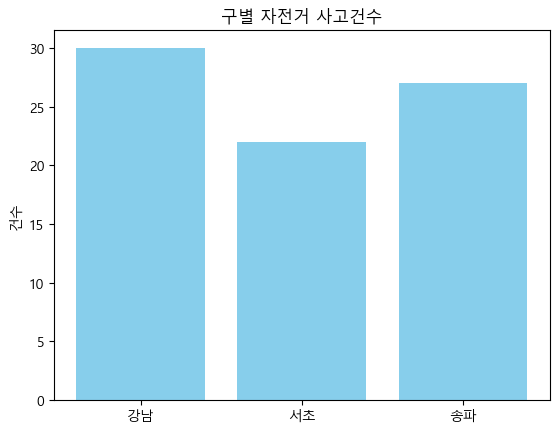

In [11]:
import matplotlib.pyplot as plt
plt.rcParams["axes.unicode_minus"] = False
# (한글 폰트 설정 먼저 — 0번/4(D) 참고)
plt.bar(['강남','서초','송파'], [30, 22, 27], color='skyblue')
plt.title('구별 자전거 사고건수'); plt.ylabel('건수')
plt.show()

In [1]:
import pymysql

con = pymysql.connect(
    host='127.0.0.1',
    user='webuser',
    password='webuser',
    database='webdb',
    charset='utf8')
print('DB 연결 성공!')

cur = con.cursor()   # 커서 생성 (SQL 실행 통로)

DB 연결 성공!


In [2]:
sql = """
CREATE TABLE news_data (
    id INT AUTO_INCREMENT PRIMARY KEY,
    cnt INT,
    title VARCHAR(255),
    description TEXT,
    link VARCHAR(255),
    pDate DATE
);
"""
cur.execute(sql)
print('테이블 생성 성공!')

테이블 생성 성공!


In [ ]:
import os
import urllib.request
import urllib.parse
import datetime
import json
import pymysql
from dotenv import load_dotenv

# 1) .env 파일의 환경변수 로드
load_dotenv()

# 2) .env에서 네이버 API 키 및 DB 정보 가져오기
client_id = os.environ.get("NAVER_CLIENT_ID")
client_secret = os.environ.get("NAVER_CLIENT_SECRET")

DB_HOST = os.environ.get("DB_HOST")
DB_USER = os.environ.get("DB_USER")
DB_PASSWORD = os.environ.get("DB_PASSWORD")
DB_NAME = os.environ.get("DB_NAME")

def getRequestUrl(url):
    req = urllib.request.Request(url)
    req.add_header("X-Naver-Client-Id", client_id)
    req.add_header("X-Naver-Client-Secret", client_secret)
    try:
        response = urllib.request.urlopen(req)
        if response.getcode() == 200:
            return response.read().decode("utf-8")
    except Exception as e:
        print("URL 요청 오류:", e)
        return None

def getNaverSearch(node, srcText, start, display):
    base = "https://openapi.naver.com/v1/search"
    node = "/%s.json" % node
    params = "?query=%s&start=%s&display=%s" % (urllib.parse.quote(srcText), start, display)
    responseDecode = getRequestUrl(base + node + params)
    return None if responseDecode is None else json.loads(responseDecode)

def saveToDB(post, cnt, cursor):
    # HTML 태그 제거 및 데이터 정제
    title = post.get('title', '').replace('<b>', '').replace('</b>', '').replace('&quot;', '"')
    description = post.get('description', '').replace('<b>', '').replace('</b>', '').replace('&quot;', '"')
    
    # 네이버 뉴스 pubDate 날짜 파싱 처리 ("Thu, 04 Jun 2026 11:34:40 +0900")
    # %z는 파이썬 버전이나 환경에 따라 간혹 포맷 오류가 날 수 있어 안전하게 슬라이싱 처리하거나 파싱합니다.
    pub_date_str = post.get('pubDate', '')
    try:
        # 끝의 타임존(+0900)을 제외한 시간까지만 파싱하기 위해 뒤의 6자리를 잘라내고 안전하게 파싱합니다.
        pDate = datetime.datetime.strptime(pub_date_str[:-6], '%a, %d %b %Y %H:%M:%S').strftime('%Y-%m-%d')
    except Exception as e:
        # 혹시 날짜 형식이 다를 경우 오늘 날짜를 기본값으로 방어
        pDate = datetime.datetime.now().strftime('%Y-%m-%d')
    
    link = post.get('link', '')
    
    sql = "INSERT INTO news_data (cnt, title, description, link, pDate) VALUES (%s, %s, %s, %s, %s)"
    cursor.execute(sql, (cnt, title, description, link, pDate))

def main():
    # 3) .env에서 가져온 연동 정보로 DB 연결
    try:
        conn = pymysql.connect(
            host=DB_HOST, 
            user=DB_USER, 
            password=DB_PASSWORD, 
            db=DB_NAME, 
            charset='utf8mb4' # 이모지나 특수문자 깨짐 방지를 위해 utf8mb4 추천
        )
        cursor = conn.cursor()
    except Exception as e:
        print("데이터베이스 연결 실패:", e)
        return

    node = 'news' 
    srcText = input('검색어를 입력하세요: ')
    cnt = 0
    
    start = 1
    while start <= 1000:
        jsonResponse = getNaverSearch(node, srcText, start, 100)
        if jsonResponse is None or 'items' not in jsonResponse or not jsonResponse['items']:
            break
            
        for post in jsonResponse['items']:
            cnt += 1
            saveToDB(post, cnt, cursor)
            
        conn.commit() # 100개 단위 루프가 끝날 때마다 데이터 안정적으로 Commit
        print(f"[{start} ~ {start + len(jsonResponse['items']) - 1}] 구간 데이터 저장 완료")
        
        start += 100
        if start > jsonResponse.get('total', 0): 
            break

    cursor.close()
    conn.close()
    print(f'총 {cnt}건의 모든 뉴스 데이터가 DB에 정상 저장되었습니다.')

if __name__ == '__main__':
    main()

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_5228\1003641619.py:66: DeprecationWarning: 'db' is deprecated, use 'database'
  main()


1 건 단위 저장 완료
101 건 단위 저장 완료
201 건 단위 저장 완료
301 건 단위 저장 완료
401 건 단위 저장 완료
501 건 단위 저장 완료
601 건 단위 저장 완료
701 건 단위 저장 완료
801 건 단위 저장 완료
901 건 단위 저장 완료
모든 데이터 저장 완료
